In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import tensorflow as tf

# for showing imgs
from PIL import Image
import glob

import matplotlib.pyplot as plt

In [9]:
model_path = "/kaggle/input/models/ashura369/sign-language-model-prediction/keras/default/1/Sign_language_model.keras"

# loading the mode
model = tf.keras.models.load_model(model_path)

# loading file names
train_path = "/kaggle/input/datasets/ashura369/indian-sign-language-dataset-0-9-and-a-z/train"
labels = sorted(os.listdir(train_path))

print(labels)


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


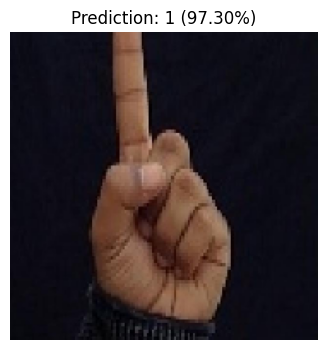

In [10]:
test_img_path = "/kaggle/input/datasets/ashura369/indian-sign-language-dataset-0-9-and-a-z/test/1"
img_list = glob.glob(os.path.join(test_img_path, "*"))
img = img_list[5]

img = tf.keras.utils.load_img(img, target_size=(180,180))
img_arr = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_arr, axis=0)      # Shape -> (1, 180, 180, 3)

predictions = model.predict(img_batch)
predicted_class = labels[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100


plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()
